In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = {
"Density":[0.916,0.915,0.914,0.914,0.913,0.912,0.912,0.911,0.910,0.910,0.909],
"Viscosity":[50.045,51.196,52.397,53.353,54.529,55.373,57.934,58.986,60.004,61.946,63.488]
}

df = pd.DataFrame(data)

df

,Density,Viscosity
0,0.916,50.045
1,0.915,51.196
2,0.914,52.397
3,0.914,53.353
4,0.913,54.529
5,0.912,55.373
6,0.912,57.934
7,0.911,58.986
8,0.910,60.004
9,0.910,61.946


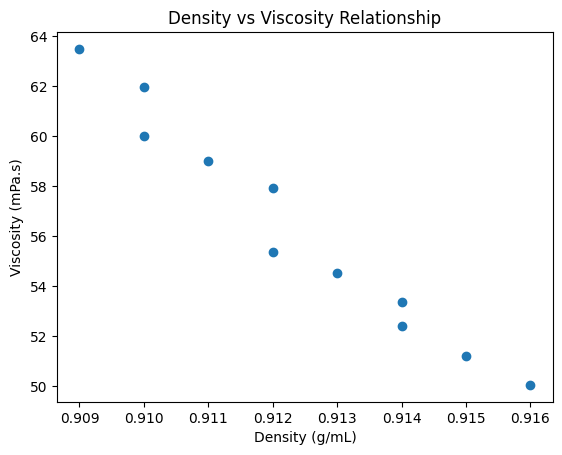

In [3]:
plt.scatter(df["Density"],df["Viscosity"])

plt.xlabel("Density (g/mL)")
plt.ylabel("Viscosity (mPa.s)")
plt.title("Density vs Viscosity Relationship")

plt.show()

In [4]:
X = df[["Density"]]   # input
y = df["Viscosity"]   # output

In [5]:
model = LinearRegression()

model.fit(X,y)

print("Model trained successfully")

Model trained successfully


In [6]:
a = model.coef_[0]
b = model.intercept_

print("Slope (a):",a)
print("Intercept (b):",b)

print("\nEquation derived from data:")
print("Viscosity =",a,"* Density +",b)

Slope (a): -1953.3938848920845
Intercept (b): 1838.5010935251785

Equation derived from data:
Viscosity = -1953.3938848920845 * Density + 1838.5010935251785


In [7]:
predicted = model.predict(X)

df["Predicted Viscosity"] = predicted

df

,Density,Viscosity,Predicted Viscosity
0,0.916,50.045,49.192295
1,0.915,51.196,51.145689
2,0.914,52.397,53.099083
3,0.914,53.353,53.099083
4,0.913,54.529,55.052477
5,0.912,55.373,57.005871
6,0.912,57.934,57.005871
7,0.911,58.986,58.959264
8,0.910,60.004,60.912658
9,0.910,61.946,60.912658


In [8]:
mse = mean_squared_error(y,predicted)
r2 = r2_score(y,predicted)

print("Mean Squared Error:",mse)
print("R2 Score:",r2)

Mean Squared Error: 0.6699762127207718
R2 Score: 0.9631951867644845


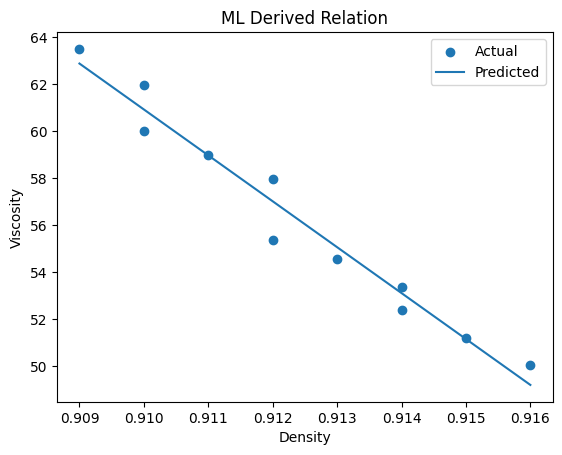

In [9]:
plt.scatter(df["Density"],df["Viscosity"],label="Actual")
plt.plot(df["Density"],predicted,label="Predicted")

plt.xlabel("Density")
plt.ylabel("Viscosity")
plt.title("ML Derived Relation")

plt.legend()

plt.show()

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [11]:
data = {
"Density":[0.916,0.915,0.914,0.914,0.913,0.912,0.912,0.911,0.910,0.910,0.909],
"Viscosity":[50.045,51.196,52.397,53.353,54.529,55.373,57.934,58.986,60.004,61.946,63.488]
}

df = pd.DataFrame(data)

X = df[['Density']]
y = df['Viscosity']

In [12]:
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

In [13]:
model = LinearRegression()
model.fit(X_poly,y)

LinearRegression()

In [14]:
a = model.coef_[2]
b = model.coef_[1]
c = model.intercept_

print("Equation derived from data:")
print("Viscosity = ",a,"* Density^2 +",b,"* Density +",c)

Equation derived from data:
Viscosity =  90438.61753152599 * Density^2 + -166994.11131688408 * Density + 77133.4597011882


In [15]:
pred = model.predict(X_poly)

df["Predicted"] = pred

df

,Density,Viscosity,Predicted
0,0.916,50.045,49.918406
1,0.915,51.196,51.319409
2,0.914,52.397,52.901289
3,0.914,53.353,52.901289
4,0.913,54.529,54.664046
5,0.912,55.373,56.607680
6,0.912,57.934,56.607680
7,0.911,58.986,58.732192
8,0.910,60.004,61.037581
9,0.910,61.946,61.037581


In [16]:
print("R2 Score:",r2_score(y,pred))

R2 Score: 0.9712811335729719


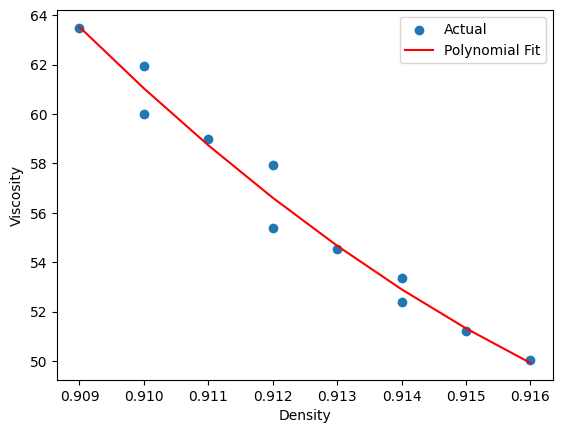

In [17]:
plt.scatter(X,y,label="Actual")

sorted_idx = np.argsort(X.values.flatten())

plt.plot(X.values.flatten()[sorted_idx],pred[sorted_idx],color='red',label="Polynomial Fit")

plt.xlabel("Density")
plt.ylabel("Viscosity")
plt.legend()
plt.show()

In [18]:
duplicate = df.groupby("Density")["Viscosity"].agg(["count","mean","min","max"])

duplicate

,count,mean,min,max
Density,,,,
0.909,1,63.4880,63.488,63.488
0.910,2,60.9750,60.004,61.946
0.911,1,58.9860,58.986,58.986
0.912,2,56.6535,55.373,57.934
0.913,1,54.5290,54.529,54.529
0.914,2,52.8750,52.397,53.353
0.915,1,51.1960,51.196,51.196
0.916,1,50.0450,50.045,50.045


In [19]:
df.groupby("Density")["Viscosity"].apply(lambda x: max(x)-min(x))

,Viscosity
Density,
0.909,0.000
0.910,1.942
0.911,0.000
0.912,2.561
0.913,0.000
0.914,0.956
0.915,0.000
0.916,0.000


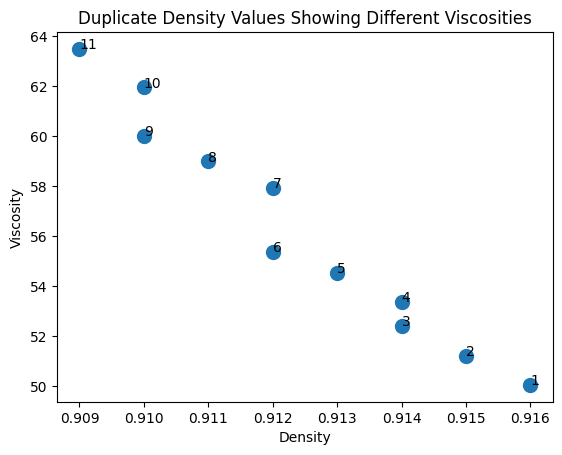

In [20]:
plt.scatter(df["Density"],df["Viscosity"],s=100)

for i in range(len(df)):
    plt.text(df["Density"][i],df["Viscosity"][i],str(i+1))

plt.xlabel("Density")
plt.ylabel("Viscosity")
plt.title("Duplicate Density Values Showing Different Viscosities")

plt.show()

In [21]:
df["Kinematic_Viscosity"] = df["Viscosity"] / df["Density"]

df

,Density,Viscosity,Predicted,Kinematic_Viscosity
0,0.916,50.045,49.918406,54.634279
1,0.915,51.196,51.319409,55.951913
2,0.914,52.397,52.901289,57.327133
3,0.914,53.353,52.901289,58.373085
4,0.913,54.529,54.664046,59.725082
5,0.912,55.373,56.607680,60.716009
6,0.912,57.934,56.607680,63.524123
7,0.911,58.986,58.732192,64.748628
8,0.910,60.004,61.037581,65.938462
9,0.910,61.946,61.037581,68.072527


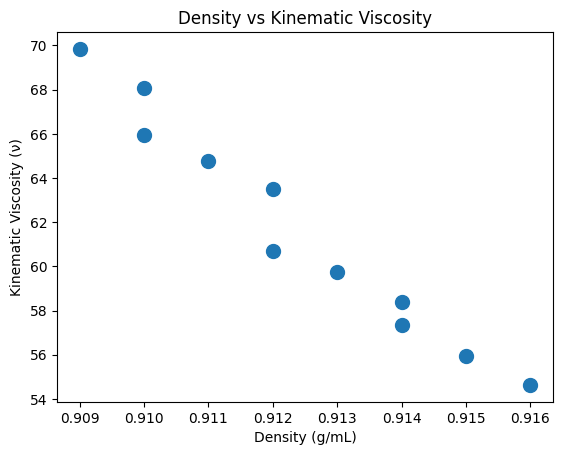

In [22]:
plt.scatter(df["Density"], df["Kinematic_Viscosity"], s=100)

plt.xlabel("Density (g/mL)")
plt.ylabel("Kinematic Viscosity (ν)")
plt.title("Density vs Kinematic Viscosity")

plt.show()

In [23]:
X = df[["Density"]]
y = df["Kinematic_Viscosity"]

from sklearn.linear_model import LinearRegression

model2 = LinearRegression()

model2.fit(X,y)

print("Model trained")

Model trained


In [24]:
a = model2.coef_[0]
b = model2.intercept_

print("Derived Relation:")
print("ν =",a,"* ρ +",b)

Derived Relation:
ν = -2208.704179041414 * ρ + 2076.855469701718


In [25]:
pred = model2.predict(X)

df["Predicted_Kinematic"] = pred

df

,Density,Viscosity,Predicted,Kinematic_Viscosity,Predicted_Kinematic
0,0.916,50.045,49.918406,54.634279,53.682442
1,0.915,51.196,51.319409,55.951913,55.891146
2,0.914,52.397,52.901289,57.327133,58.099850
3,0.914,53.353,52.901289,58.373085,58.099850
4,0.913,54.529,54.664046,59.725082,60.308554
5,0.912,55.373,56.607680,60.716009,62.517258
6,0.912,57.934,56.607680,63.524123,62.517258
7,0.911,58.986,58.732192,64.748628,64.725963
8,0.910,60.004,61.037581,65.938462,66.934667
9,0.910,61.946,61.037581,68.072527,66.934667


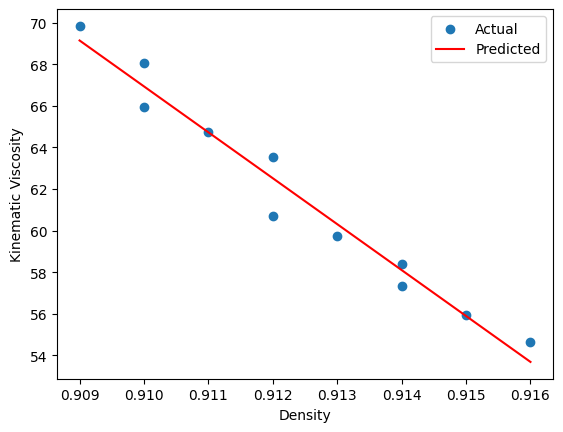

In [26]:
plt.scatter(df["Density"], df["Kinematic_Viscosity"], label="Actual")

plt.plot(df["Density"], pred, color="red", label="Predicted")

plt.xlabel("Density")
plt.ylabel("Kinematic Viscosity")

plt.legend()

plt.show()

In [1]:
!pip install gplearn

In [4]:
#imort the symbolic regression model and install symbolic regressn lib above
from gplearn.genetic import SymbolicRegressor

In [5]:
import pandas as pd

data = {
"Density":[0.916,0.915,0.914,0.914,0.913,0.912,0.912,0.911,0.910,0.910,0.909],
"Viscosity":[50.045,51.196,52.397,53.353,54.529,55.373,57.934,58.986,60.004,61.946,63.488]
}

df = pd.DataFrame(data)

df

,Density,Viscosity
0,0.916,50.045
1,0.915,51.196
2,0.914,52.397
3,0.914,53.353
4,0.913,54.529
5,0.912,55.373
6,0.912,57.934
7,0.911,58.986
8,0.910,60.004
9,0.910,61.946


In [6]:
X = df[['Density']].values
y = df['Viscosity'].values

In [7]:
#train the symb regressn model
model_sr = SymbolicRegressor(
    population_size=2000,
    generations=20,
    stopping_criteria=0.01,
    p_crossover=0.7,
    p_subtree_mutation=0.1,
    p_hoist_mutation=0.05,
    p_point_mutation=0.1,
    max_samples=0.9,
    verbose=1,
    random_state=0
)

model_sr.fit(X, y)

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    46.41          177.726       31          1.21842           2.3076     32.99s
   1    61.93           79.126       31           1.0241          1.10881     29.41s
   2    83.41          129.842       31         0.879432           1.7598     40.92s
   3    92.65          180.904       29          0.75408          1.16091     30.88s
   4    78.76          203.233       29         0.686566          1.46472     28.15s
   5    78.42          301.135      127          0.58637          1.99184     25.88s
   6    82.78          651.923       37         0.605648          1.43965     24.82s
   7    83.12          434.698       27         0.607694          1.60695     22.64s
   8    77.59          337.399       77         0.572496          1.87234  

,population_size,2000
,generations,20
,tournament_size,20
,stopping_criteria,0.01
,const_range,"(-1.0, ...)"
,init_depth,"(2, ...)"
,init_method,'half and half'
,function_set,"('add', ...)"
,metric,'mean absolute error'
,parsimony_coefficient,0.001
,p_crossover,0.7


In [8]:
print(model_sr._program)

div(add(sub(add(X0, X0), div(X0, X0)), sub(div(X0, -0.159), sub(X0, -0.971))), div(div(add(-0.888, X0), div(-0.593, -0.353)), mul(mul(-0.273, X0), sub(X0, 0.426))))


In [9]:
#formula is above
#predict viscosity using formula
pred_sr = model_sr.predict(X)

df["Symbolic_Prediction"] = pred_sr

df

,Density,Viscosity,Symbolic_Prediction
0,0.916,50.045,49.643504
1,0.915,51.196,51.255062
2,0.914,52.397,52.989245
3,0.914,53.353,52.989245
4,0.913,54.529,54.860539
5,0.912,55.373,56.885807
6,0.912,57.934,56.885807
7,0.911,58.986,59.084797
8,0.910,60.004,61.480784
9,0.910,61.946,61.480784


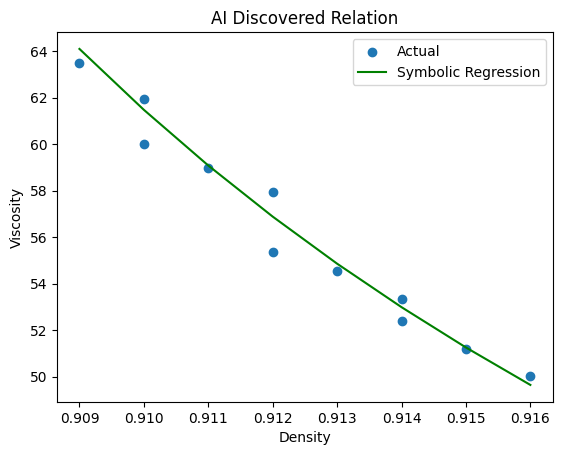

In [10]:
import matplotlib.pyplot as plt

plt.scatter(df["Density"], df["Viscosity"], label="Actual")

plt.plot(df["Density"], pred_sr, color="green", label="Symbolic Regression")

plt.xlabel("Density")
plt.ylabel("Viscosity")
plt.title("AI Discovered Relation")

plt.legend()

plt.show()

In [11]:
df.groupby("Density")["Viscosity"].agg(["count","mean","min","max"])

,count,mean,min,max
Density,,,,
0.909,1,63.4880,63.488,63.488
0.910,2,60.9750,60.004,61.946
0.911,1,58.9860,58.986,58.986
0.912,2,56.6535,55.373,57.934
0.913,1,54.5290,54.529,54.529
0.914,2,52.8750,52.397,53.353
0.915,1,51.1960,51.196,51.196
0.916,1,50.0450,50.045,50.045


In [14]:
data = {
"density":[0.916,0.915,0.914,0.914,0.913,0.912,0.912,0.911,0.910,0.910,0.909],
"olive_percent":[0,10,20,30,40,50,60,70,80,90,100],
"viscosity":[50.045,51.196,52.397,53.353,54.529,55.373,57.934,58.986,60.004,61.946,63.488]
}

df = pd.DataFrame(data)

X = df[["density","olive_percent"]]
y = df["viscosity"]

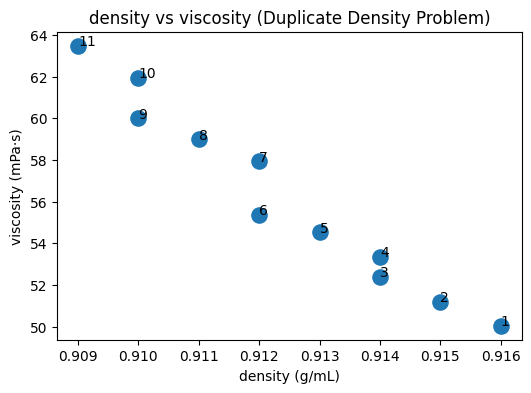

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(df["density"], df["viscosity"], s=120)

for i in range(len(df)):
    plt.text(df["density"][i], df["viscosity"][i], str(i+1))

plt.xlabel("density (g/mL)")
plt.ylabel("viscosity (mPa·s)")
plt.title("density vs viscosity (Duplicate Density Problem)")

plt.show()

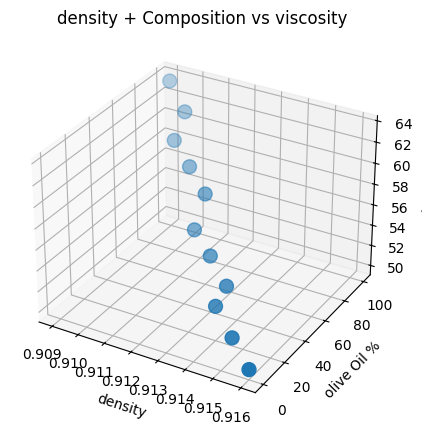

In [17]:
#3D graph: Density + Composition → Viscosity
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

composition = np.array([0,10,20,30,40,50,60,70,80,90,100])

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df["density"], composition, df["viscosity"], s=100)

ax.set_xlabel("density")
ax.set_ylabel("olive Oil %")
ax.set_zlabel("viscosity")

ax.set_title("density + Composition vs viscosity")

plt.show()

In [18]:
#What this graph shows

#Viscosity changes with both density and composition.

#So the real relation is:

#μ=f(ρ,composition)

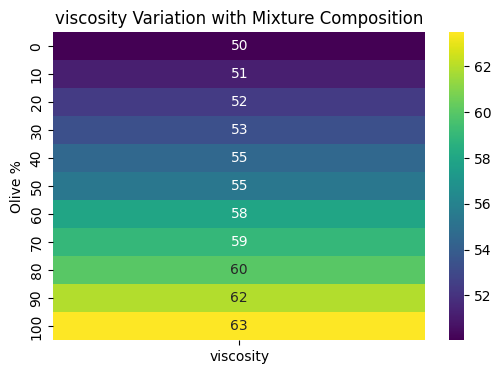

In [20]:
#Heatmap of viscosity vs mixture ratio
import seaborn as sns

heat_data = pd.DataFrame({
"Olive %":composition,
"viscosity":df["viscosity"]
})

plt.figure(figsize=(6,4))

sns.heatmap(heat_data.set_index("Olive %"), cmap="viridis", annot=True)

plt.title("viscosity Variation with Mixture Composition")

plt.show()

In [21]:
#Graph 1
#Density vs viscosity scatter
#➡ proves duplicate density issue

#Graph 2
#3D relationship
#➡ shows viscosity depends on density + composition

#Graph 3
#Heatmap
#➡ shows viscosity increases with olive oil %

#Observation
#Multiple samples exhibit identical density values but different viscosities.

#Interpretation
#Viscosity depends not only on density but also on the composition of the oil mixture.

#Conclusion
#Machine learning models using only density cannot uniquely predict viscosity.Including mixture composition improves prediction accuracy.